In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.fetch_nasa_omni_historical import load_and_clean_nasa_omni_historical
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
omni_2023 = load_and_clean_nasa_omni_historical(2023, "../data/raw/")
print(f"OMNI 2023 shape: {omni_2023.shape}")
print(f"Date range: {omni_2023.index.min()} to {omni_2023.index.max()}")
print("\nFirst few rows:")
print(omni_2023.head())
print("\nData types:")
print(omni_2023.dtypes)

2026-03-04 14:27:26,269 - INFO - Found existing raw data file for year 2023 at ../data/raw/omni2_2023_raw.csv. Loading...


OMNI 2023 shape: (8760, 11)
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00

First few rows:
                     Year  DOY  Hour  IMF_Mag  Bx_GSE  By_GSE  Bz_GSE  \
Timestamp                                                               
2023-01-01 00:00:00  2023  1.0     0     -1.9     4.6    -0.7     4.6   
2023-01-01 01:00:00  2023  1.0     1     -3.9    -0.6     0.6    -0.7   
2023-01-01 02:00:00  2023  1.0     2     -3.9    -1.2     1.5    -1.5   
2023-01-01 03:00:00  2023  1.0     3     -3.4     1.5     0.4     1.4   
2023-01-01 04:00:00  2023  1.0     4     -2.4     2.7     0.7     2.6   

                     Proton_Density  Plasma_Speed  Kp_index  Kp_real  
Timestamp                                                             
2023-01-01 00:00:00             2.4         603.0        23      2.3  
2023-01-01 01:00:00             2.6         582.0        23      2.3  
2023-01-01 02:00:00             2.6         581.0        23      2.3  
2023-01-01 03:00:00             2

In [5]:
print("\n=== DESCRIPTIVE STATISTICS ===")
# print(omni_2023.describe())
print("\nSkewness:")
print(omni_2023.skew())
print("\nKurtosis:")
print(omni_2023.kurtosis())


=== DESCRIPTIVE STATISTICS ===

Skewness:
Year              0.000000e+00
DOY              -1.810284e-07
Hour              0.000000e+00
IMF_Mag          -1.682085e-01
Bx_GSE           -3.906891e-01
By_GSE            3.487526e-01
Bz_GSE           -2.206106e-01
Proton_Density    3.112918e+00
Plasma_Speed      9.350222e-01
Kp_index          8.850662e-01
Kp_real           8.850662e-01
dtype: float64

Kurtosis:
Year               0.000000
DOY               -1.200018
Hour              -1.204176
IMF_Mag           -0.209089
Bx_GSE             3.026515
By_GSE             8.248310
Bz_GSE             3.670385
Proton_Density    16.683207
Plasma_Speed       0.652921
Kp_index           1.054300
Kp_real            1.054300
dtype: float64


In [6]:
missing_counts = omni_2023.isna().sum()
missing_pct = (omni_2023.isna().sum() / len(omni_2023)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] >= 0])

                Missing Count  Percentage
Year                        0         0.0
DOY                         0         0.0
Hour                        0         0.0
IMF_Mag                     0         0.0
Bx_GSE                      0         0.0
By_GSE                      0         0.0
Bz_GSE                      0         0.0
Proton_Density              0         0.0
Plasma_Speed                0         0.0
Kp_index                    0         0.0
Kp_real                     0         0.0


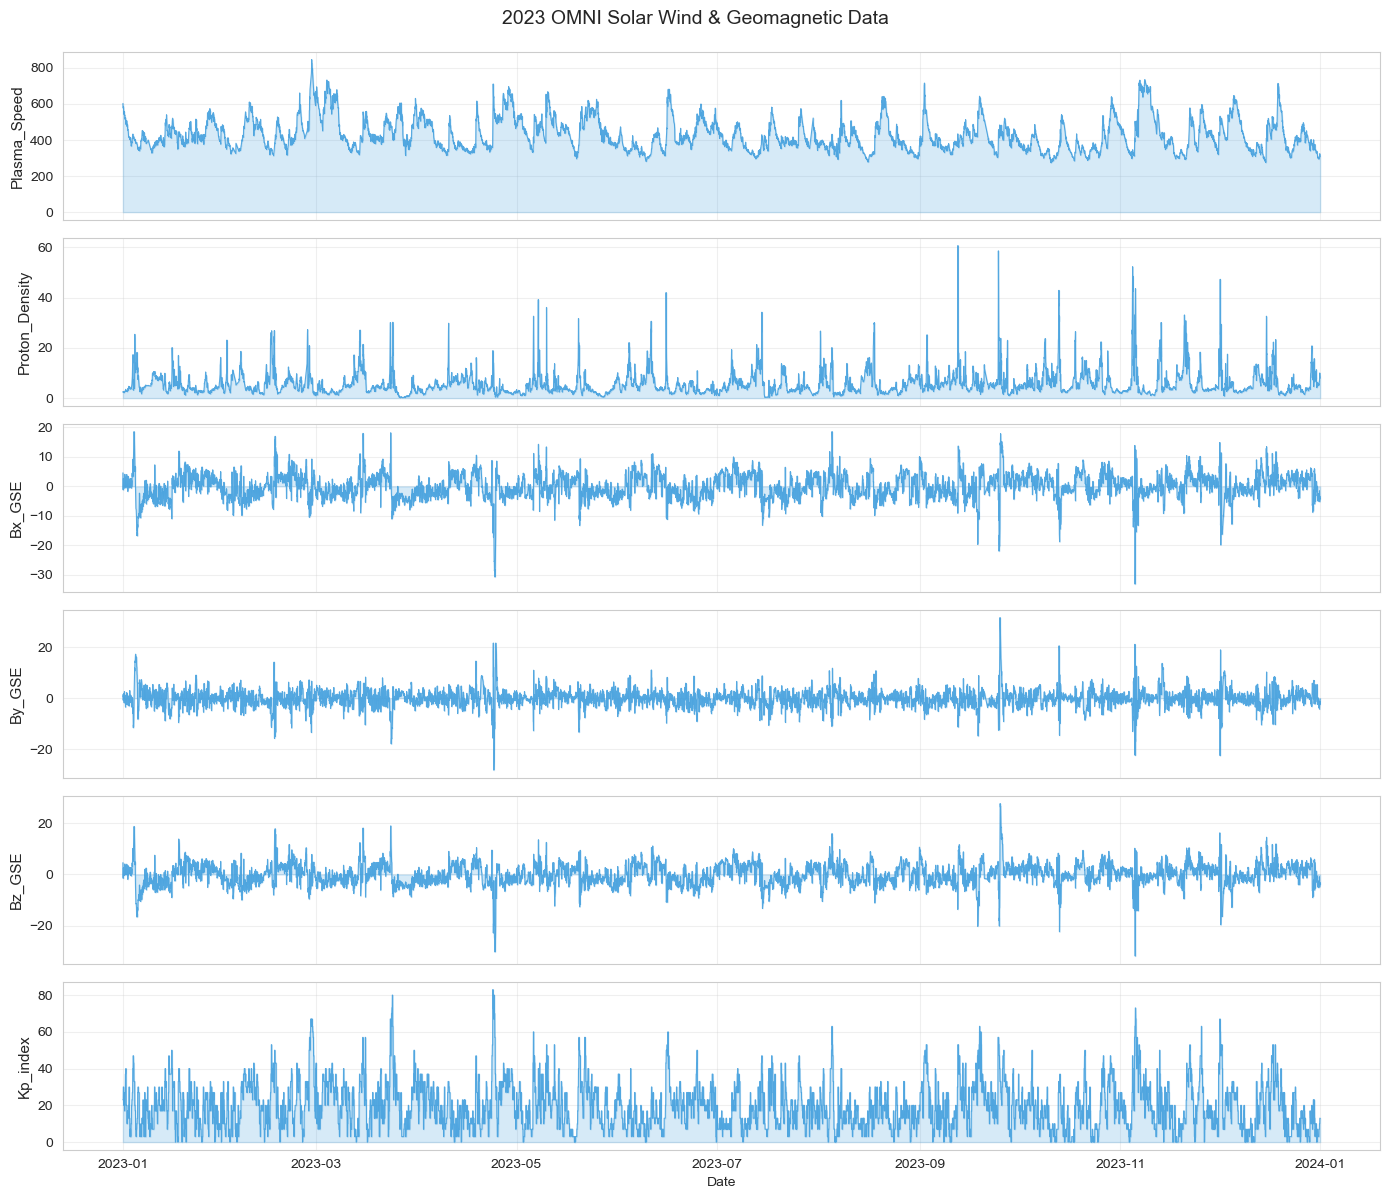

In [4]:
features = ['Plasma_Speed', 'Proton_Density', 'Bx_GSE', 'By_GSE', 'Bz_GSE', 'Kp_index']
fig, axes = plt.subplots(len(features), 1, figsize=(14, 12), sharex=True)

for i, feature in enumerate(features):
    axes[i].plot(omni_2023.index, omni_2023[feature], linewidth=0.8, color='#3498db', alpha=0.8)
    axes[i].set_ylabel(feature, fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].fill_between(omni_2023.index, omni_2023[feature], alpha=0.2, color='#3498db')

axes[-1].set_xlabel('Date')
fig.suptitle('2023 OMNI Solar Wind & Geomagnetic Data', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

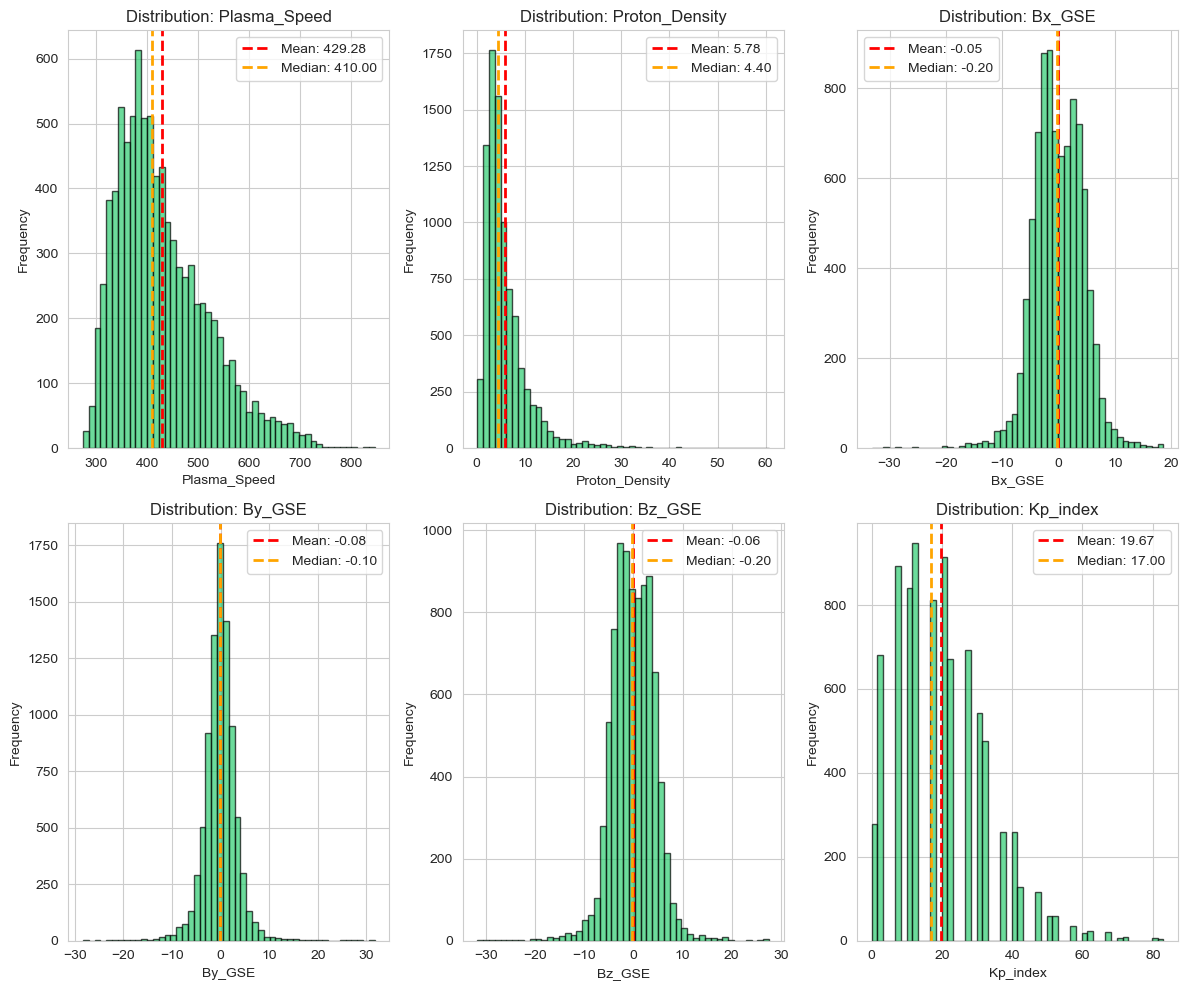

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    data_clean = omni_2023[feature].dropna()
    axes[i].hist(data_clean, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution: {feature}')
    axes[i].axvline(data_clean.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data_clean.mean():.2f}')
    axes[i].axvline(data_clean.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {data_clean.median():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

Plasma_Speed: 187 outliers (2.13%)
Proton_Density: 513 outliers (5.86%)
Bx_GSE: 136 outliers (1.55%)
By_GSE: 411 outliers (4.69%)
Bz_GSE: 140 outliers (1.60%)
Kp_index: 183 outliers (2.09%)


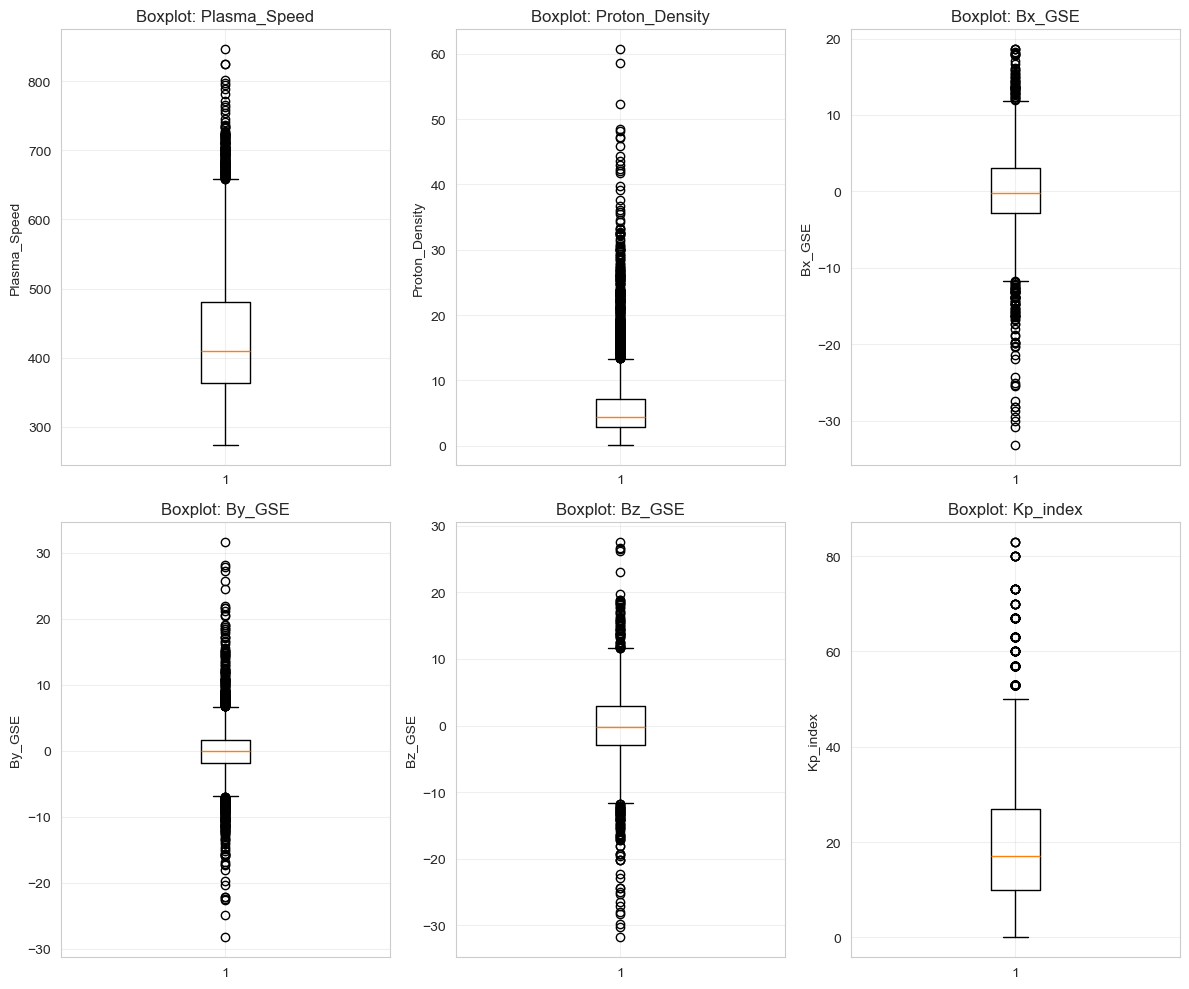

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    data_clean = omni_2023[feature].dropna()
    Q1 = data_clean.quantile(0.25)
    Q3 = data_clean.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data_clean[(data_clean < lower_bound) | (data_clean > upper_bound)]
    print(f"{feature}: {len(outliers)} outliers ({100*len(outliers)/len(data_clean):.2f}%)")
    
    axes[i].boxplot(data_clean, vert=True)
    axes[i].set_ylabel(feature)
    axes[i].set_title(f'Boxplot: {feature}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



=== CORRELATION ANALYSIS ===
                Plasma_Speed  Proton_Density    Bx_GSE    By_GSE    Bz_GSE  \
Plasma_Speed        1.000000       -0.295204 -0.125827  0.008102 -0.121303   
Proton_Density     -0.295204        1.000000  0.042293 -0.070151  0.041241   
Bx_GSE             -0.125827        0.042293  1.000000  0.006101  0.964371   
By_GSE              0.008102       -0.070151  0.006101  1.000000  0.012906   
Bz_GSE             -0.121303        0.041241  0.964371  0.012906  1.000000   
Kp_index            0.476156        0.247513 -0.062558 -0.341974 -0.046364   

                Kp_index  
Plasma_Speed    0.476156  
Proton_Density  0.247513  
Bx_GSE         -0.062558  
By_GSE         -0.341974  
Bz_GSE         -0.046364  
Kp_index        1.000000  


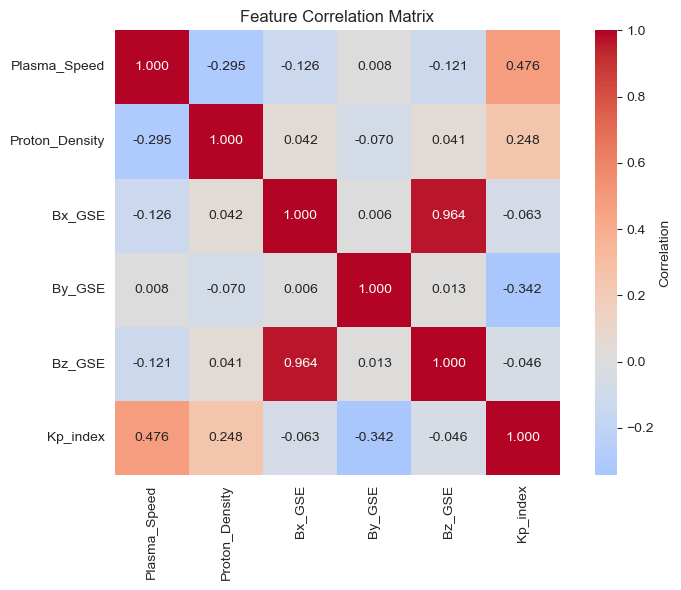

In [12]:
print("\n=== CORRELATION ANALYSIS ===")
corr_matrix = omni_2023[features].corr()
print(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.show()


Generating pairwise scatterplots...


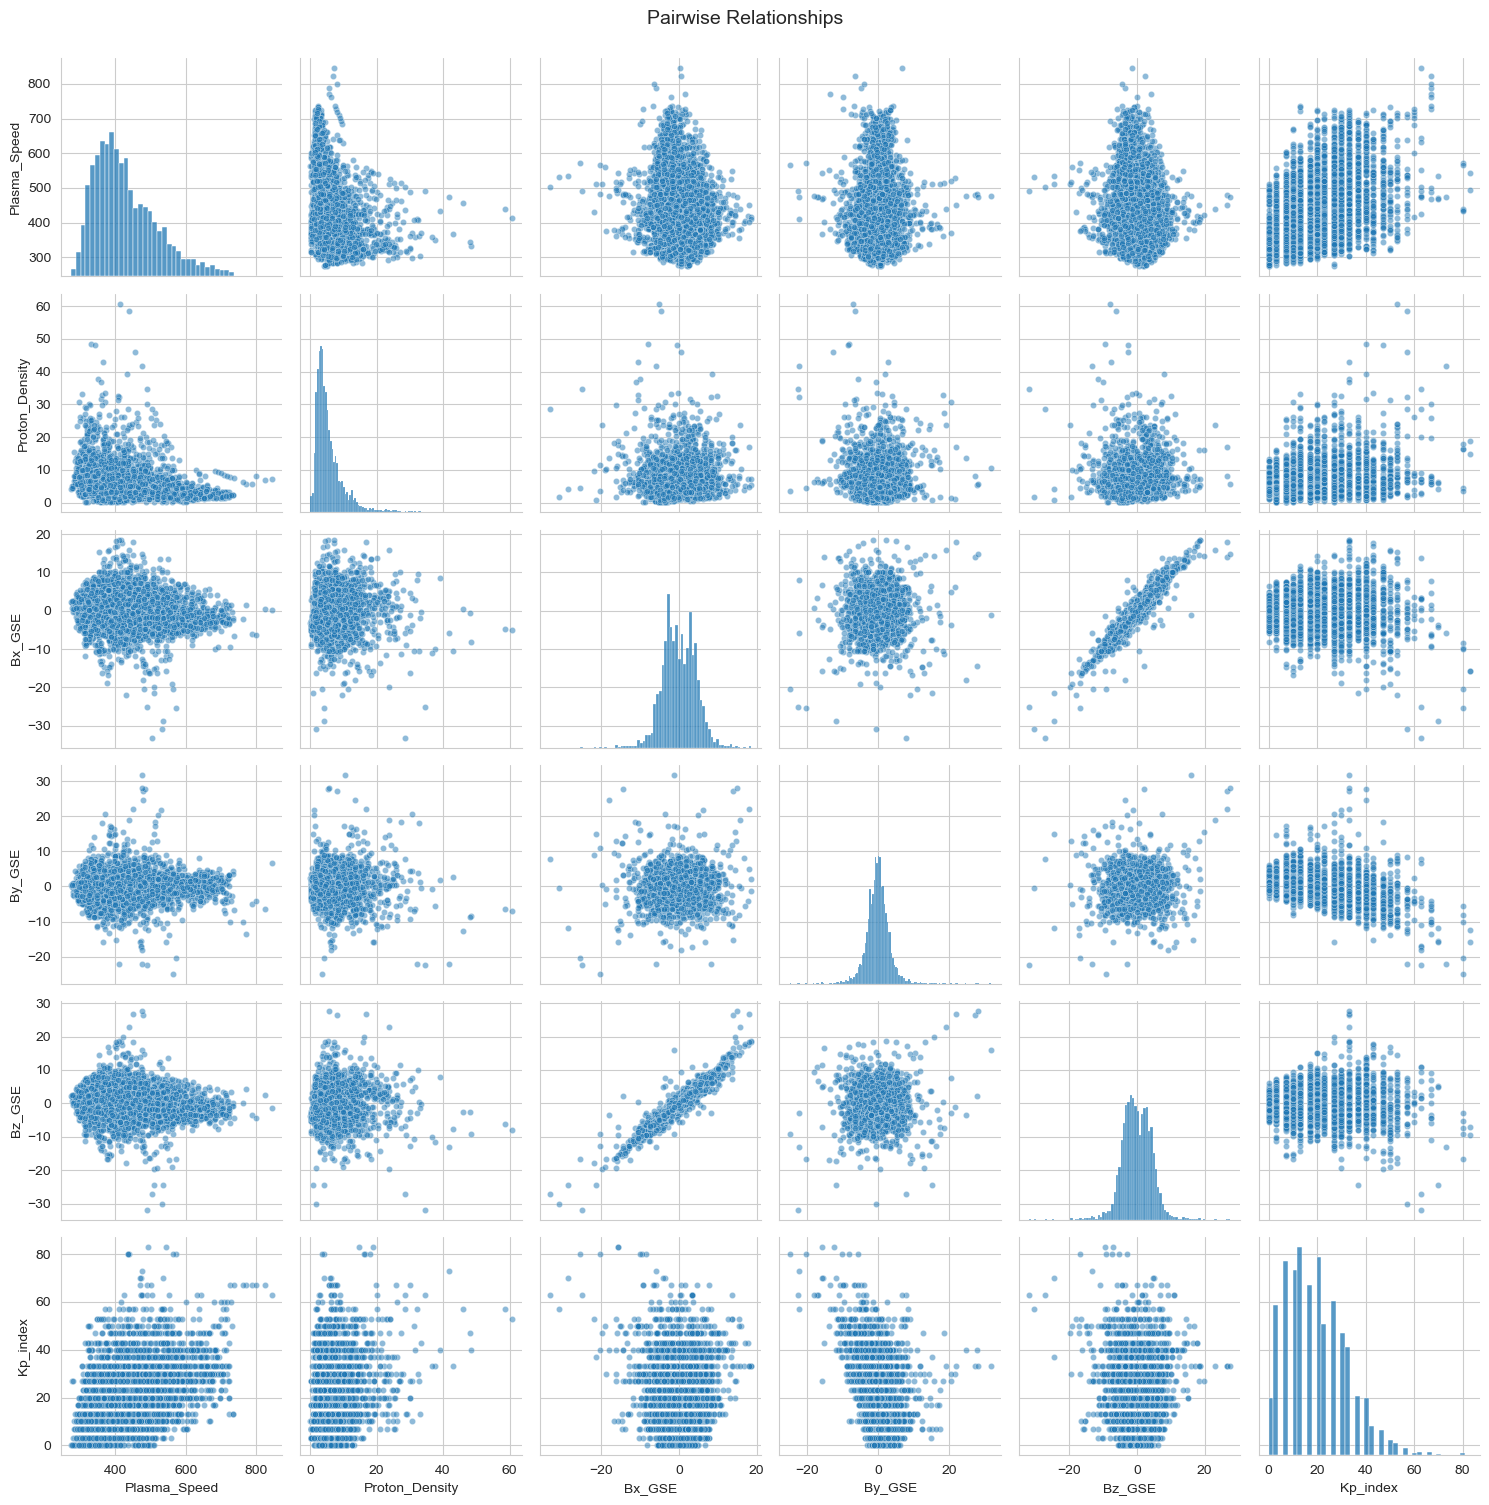

In [13]:
print("\nGenerating pairwise scatterplots...")
pairplot_data = omni_2023[features].dropna().sample(min(5000, len(omni_2023)), random_state=42)
sns.pairplot(pairplot_data, diag_kind='hist', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairwise Relationships', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()


Kp_index vs. Features...


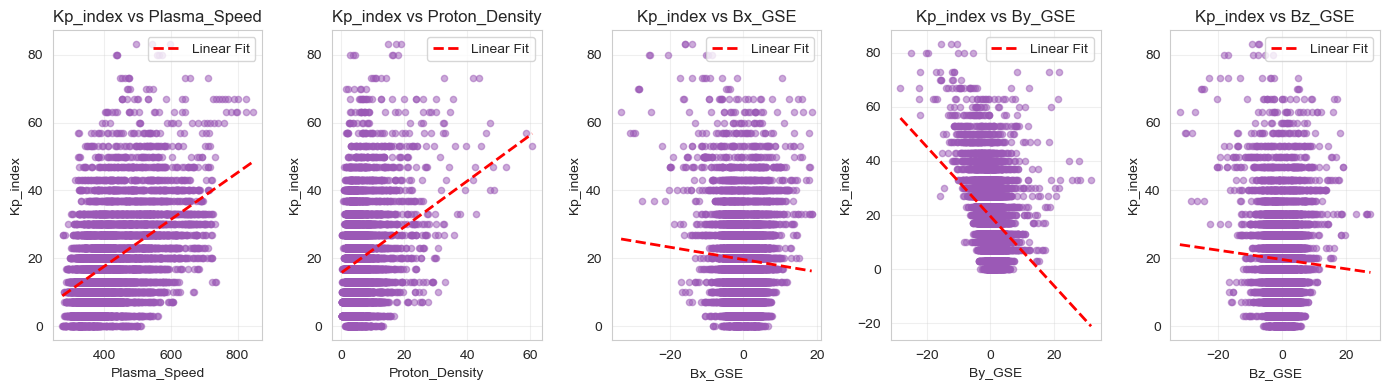

In [16]:
print("\nKp_index vs. Features...")
fig, axes = plt.subplots(1, 5, figsize=(14, 4))

scatter_features = ['Plasma_Speed', 'Proton_Density', 'Bx_GSE', 'By_GSE', 'Bz_GSE']
for i, feature in enumerate(scatter_features):
    data = omni_2023[[feature, 'Kp_index']].dropna()
    axes[i].scatter(data[feature], data['Kp_index'], alpha=0.5, s=20, color='#9b59b6')
    
    # Add regression line
    z = np.polyfit(data[feature], data['Kp_index'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[feature].min(), data[feature].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=2, label=f'Linear Fit')
    
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Kp_index')
    axes[i].set_title(f'Kp_index vs {feature}')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()


=== AUTOCORRELATION ANALYSIS ===


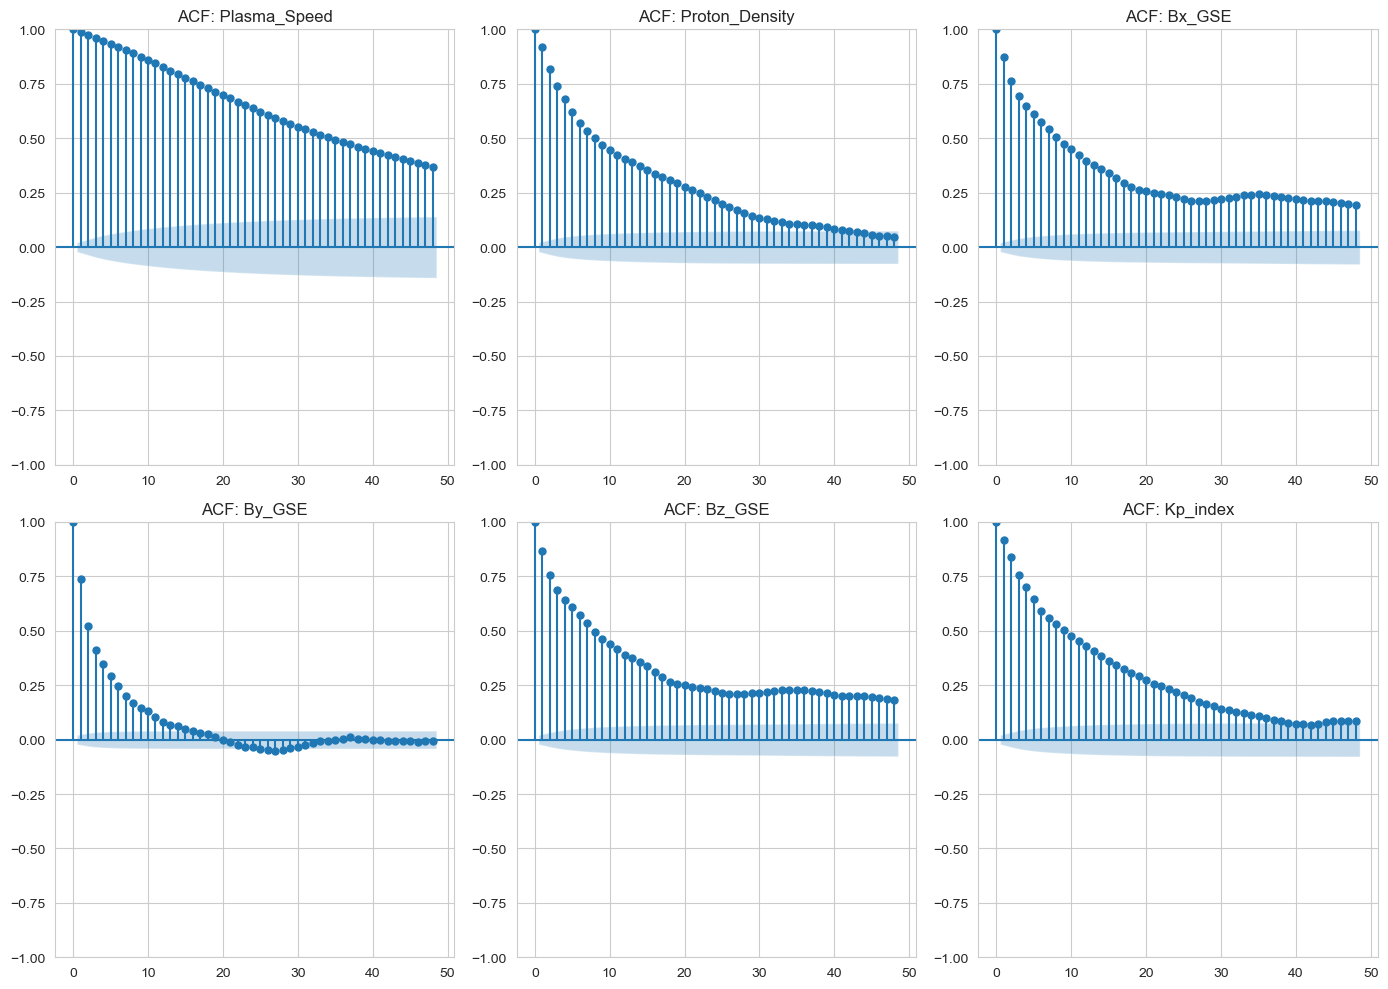

In [19]:
print("\n=== AUTOCORRELATION ANALYSIS ===")
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

for i, feature in enumerate(features):
    ax_row = i // 3
    ax_col = i % 3
    
    data_clean = omni_2023[feature].dropna()
    
    if ax_col == 0:
        plot_acf(data_clean, lags=48, ax=axes[ax_row, ax_col], title=f'ACF: {feature}')
    else:
        plot_acf(data_clean, lags=48, ax=axes[ax_row, ax_col], title=f'ACF: {feature}')

plt.tight_layout()
plt.show()


Lag analysis: How solar wind features predict Kp_index...


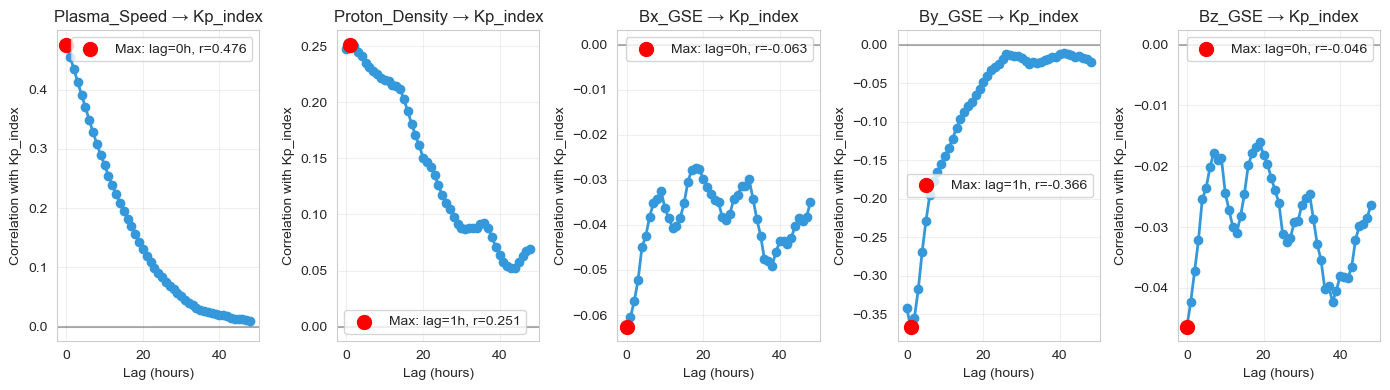

In [21]:
print("\nLag analysis: How solar wind features predict Kp_index...")
fig, axes = plt.subplots(1, 5, figsize=(14, 4))

lags_to_test = np.arange(0, 49, 1)
features_for_lag = ['Plasma_Speed', 'Proton_Density', 'Bx_GSE', 'By_GSE', 'Bz_GSE']

for i, feature in enumerate(features_for_lag):
    lag_correlations = []
    
    for lag in lags_to_test:
        shifted = omni_2023[feature].shift(lag)
        corr = shifted.corr(omni_2023['Kp_index'])
        lag_correlations.append(corr)
    
    axes[i].plot(lags_to_test, lag_correlations, marker='o', linestyle='-', linewidth=2, color='#3498db')
    axes[i].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[i].set_xlabel('Lag (hours)')
    axes[i].set_ylabel('Correlation with Kp_index')
    axes[i].set_title(f'{feature} → Kp_index')
    axes[i].grid(True, alpha=0.3)
    
    # Mark max correlation
    max_lag = lags_to_test[np.argmax(np.abs(lag_correlations))]
    max_corr = lag_correlations[np.argmax(np.abs(lag_correlations))]
    axes[i].scatter([max_lag], [max_corr], color='red', s=100, zorder=5, label=f'Max: lag={max_lag}h, r={max_corr:.3f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [18]:
print("\n=== EDA SUMMARY ===")
print(f"Dataset spans: {omni_2023.index.min()} to {omni_2023.index.max()}")
print(f"Total observations: {len(omni_2023)}")
print(f"Complete cases (no NaN): {omni_2023.dropna().shape[0]}")
print(f"\nFeatures: {', '.join(features)}")
print(f"Target: Kp_index")
print(f"\nKey findings:")
print(f"  - Check correlation heatmap for multicollinearity")
print(f"  - ACF/PACF shows temporal dependencies (important for lag models)")
print(f"  - Lag analysis reveals optimal lead times for prediction")


=== EDA SUMMARY ===
Dataset spans: 2023-01-01 00:00:00 to 2023-12-31 23:00:00
Total observations: 8760
Complete cases (no NaN): 8760

Features: Plasma_Speed, Proton_Density, Bz_GSE, Kp_index
Target: Kp_index

Key findings:
  - Check correlation heatmap for multicollinearity
  - ACF/PACF shows temporal dependencies (important for lag models)
  - Lag analysis reveals optimal lead times for prediction


# Derived features

Transformer-generated features: ['Year', 'DOY', 'Hour', 'IMF_Mag', 'Kp_real', 'lag_min', 'Bz_South', 'Energy_Flux', 'Energy_3h_Avg', 'Speed_6h_Max', 'B_total', 'B_azimuth']

Correlation with Kp_index:
Kp_real          1.000000
Speed_6h_Max     0.455297
B_total          0.369575
Energy_3h_Avg    0.259155
Energy_Flux      0.249583
Bz_South         0.180205
Hour             0.017018
IMF_Mag         -0.002553
DOY             -0.077782
B_azimuth       -0.205915
lag_min         -0.469292
Year                  NaN
Name: Kp_index, dtype: float64


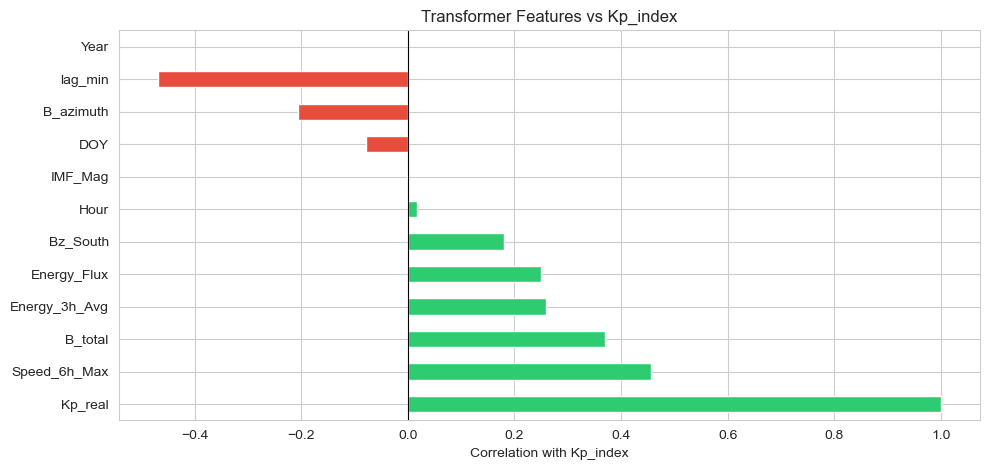

In [8]:
sys.path.insert(0, str(Path.cwd().parent))

from src.features.transformers import *

omni_2023 = SolarWindTransformer.transform(omni_2023)
# Get all transformer-generated features
transformer_features = [col for col in omni_2023.columns if col not in features]

print(f"Transformer-generated features: {transformer_features}")

# Calculate correlations with Kp_index
if transformer_features:
    kp_corr = omni_2023[transformer_features + ['Kp_index']].corr()['Kp_index'].drop('Kp_index').sort_values(ascending=False)
    print("\nCorrelation with Kp_index:")
    print(kp_corr)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, len(transformer_features) * 0.4))
    kp_corr.plot(kind='barh', ax=ax, color=['#2ecc71' if x > 0 else '#e74c3c' for x in kp_corr.values])
    ax.set_xlabel('Correlation with Kp_index')
    ax.set_title('Transformer Features vs Kp_index')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("No transformer-generated features found in the dataset")

Correlation with Kp_index (all features):
Kp_real           1.000000
Plasma_Speed      0.476156
Speed_6h_Max      0.455297
B_total           0.369575
Energy_3h_Avg     0.259155
Energy_Flux       0.249583
Proton_Density    0.247513
Bz_South          0.180205
Hour              0.017018
IMF_Mag          -0.002553
Bz_GSE           -0.046364
Bx_GSE           -0.062558
DOY              -0.077782
B_azimuth        -0.205915
By_GSE           -0.341974
lag_min          -0.469292
Name: Kp_index, dtype: float64


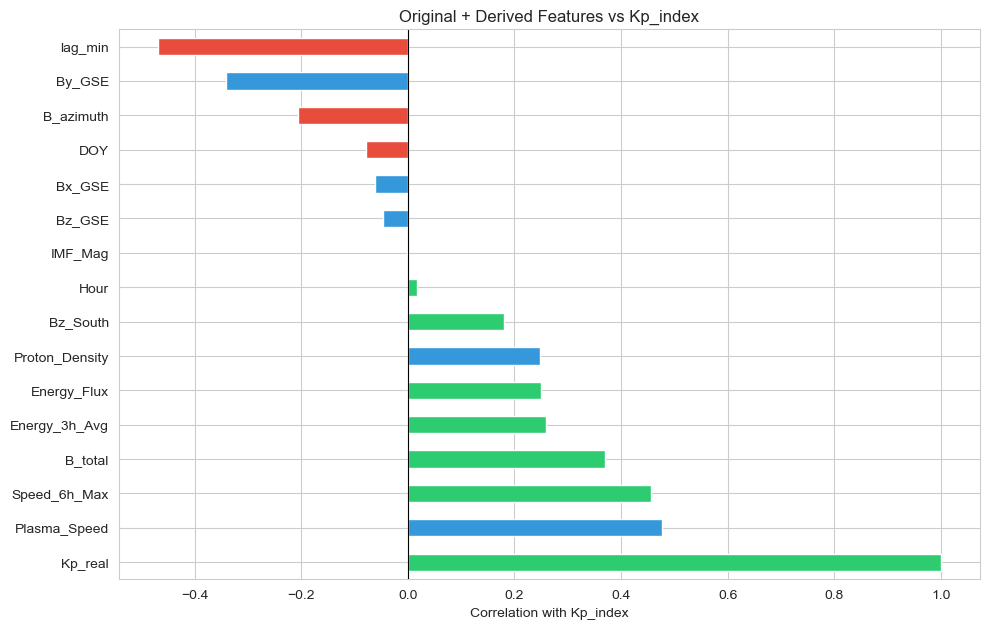

In [9]:
# Include both original (non-derived) and transformer-generated features in one plot
base_features = [f for f in features if f != "Kp_index"]
all_features_for_plot = list(dict.fromkeys(base_features + transformer_features))

kp_corr_all = (
    omni_2023[all_features_for_plot + ["Kp_index"]]
    .corr(numeric_only=True)["Kp_index"]
    .drop("Kp_index")
    .dropna()
    .sort_values(ascending=False)
)

print("Correlation with Kp_index (all features):")
print(kp_corr_all)

# Color by feature type
color_map = [
    "#3498db" if f in base_features else "#2ecc71" if v > 0 else "#e74c3c"
    for f, v in kp_corr_all.items()
]

fig, ax = plt.subplots(figsize=(10, max(5, len(kp_corr_all) * 0.4)))
kp_corr_all.plot(kind="barh", ax=ax, color=color_map)
ax.set_xlabel("Correlation with Kp_index")
ax.set_title("Original + Derived Features vs Kp_index")
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.8)
plt.tight_layout()
plt.show()